# Random Forest — Feature Selection

This notebook documents the first Random Forest iteration for predicting whether a labelled SKU would be sold.

The analysis includes exploratory analysis, model training, evaluation and feature selection, with particular attention to the influence of Brand 2.

> **Data availability:** The original project datasets are not included in this public repository. Place the processed input files in `../data/` using the filenames referenced below.


## Load and Merge Product and Store Data


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
from pathlib import Path

DATA_DIR = Path("../data")

df1 = pd.read_excel(DATA_DIR / "products_ML.xlsx")
df2 = pd.read_excel(DATA_DIR / "cleaned_store.xlsx")


In [ ]:
df = pd.merge(df1, df2, on='idstore', how='left')

## Exploratory Data Analysis


During dashboard preparation, we identified that one brand had substantially higher sales than the others. We explored this pattern further in the modelling dataset.


/tmp/ipykernel_629/1677325672.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='brand', y='percentage_sold_global', data=brand_sku_summary_sorted_top_10, palette='rocket')


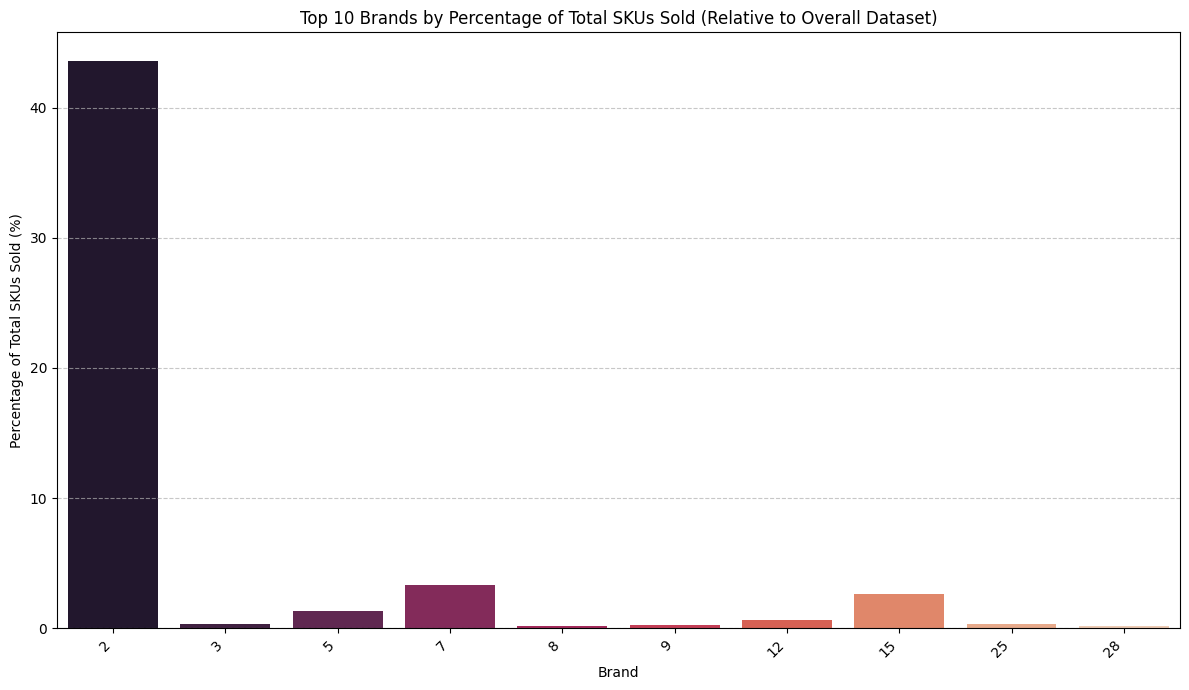

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calcular os SKU Sold por marca
sold_skus_per_brand = df[df['sold'] == 1].groupby('brand')['sku'].count().reset_index()
sold_skus_per_brand.rename(columns={'sku': 'sold_skus'}, inplace=True)

# Total the Skus no dataset
total_skus_overall = len(df)

# Agrupar por marca
all_brands = df[['brand']].drop_duplicates()
brand_sku_summary_global_pct = pd.merge(all_brands, sold_skus_per_brand, on='brand', how='left')

# Preencher os Nan 'sold_skus' com 0
brand_sku_summary_global_pct['sold_skus'] = brand_sku_summary_global_pct['sold_skus'].fillna(0)

# Calcular a percentagem de SKUs vendidos face ao total
brand_sku_summary_global_pct['percentage_sold_global'] = (brand_sku_summary_global_pct['sold_skus'] / total_skus_overall) * 100

# Ordenar e top10
brand_sku_summary_sorted_top_10 = brand_sku_summary_global_pct.sort_values(by='percentage_sold_global', ascending=).head(10)

plt.figure(figsize=(12, 7))
sns.barplot(x='brand', y='percentage_sold_global', data=brand_sku_summary_sorted_top_10, palette='rocket')
plt.xlabel('Brand')
plt.ylabel('Percentage of Total SKUs Sold (%)')
plt.title('Top 10 Brands by Percentage of Total SKUs Sold (Relative to Overall Dataset)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Model Development


Percebemos que a marca 2 realmente vendia muito mais que as outras. Decidimos assim criar uma feature atravez de one hot encoding para poder dar essa informacao ao nosso modelo. Vamos tambem usar outras features que achamos pertinentes para o negocio e criar outra para quando o labelling occore ao fim de semana.

In [ ]:
df['is_brand_2'] = (df['brand'] == 2).astype(int)
display(df[['brand', 'is_brand_2']].head())

,brand,is_brand_2
0,2,1
1,7,0
2,7,0
3,7,0
4,7,0


In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.inspection import permutation_importance

# =========================================================
# STEP 1: Split do Dataset
# =========================================================

train_raw, test_raw = train_test_split(
    df,
    test_size=0.20,
    random_state=42,
    stratify=df['sold']
)

print(f"Train rows: {len(train_raw)} | Testing rows: {len(test_raw)}")


# =========================================================
# STEP 2: Criar algumas features adicionais
# =========================================================
def engineer_features(train_df, eval_df=None):
    """
    Applies feature engineering cleanly.
    Statistics (e.g. store inventory counts) are computed STRICTLY on train_df
    and mapped onto train_df and optional eval_df (val or test).
    """
    train_df = train_df.copy()

    splits = [train_df]
    if eval_df is not None:
        eval_df = eval_df.copy()
        splits.append(eval_df)

    # 1. Labelling ao fim de semana
    for df_split in splits:
        df_split['labelling_day_of_week'] = df_split['labelling_date'].dt.dayofweek
        df_split['is_weekend_labelling'] = (df_split['labelling_day_of_week'] >= 5).astype(int)


    if eval_df is not None:
        return train_df, eval_df
    return train_df


# Lista das feature que vamos usar
features = [
    'discount', 'Margin (%)', 'Profit (€)', 'new_pvp',

    'days_until_expiration', 'is_weekend_labelling',

    'selling_square_ft', 'is_brand_2'
]


# =========================================================
# STEP 3: STRATIFIED 5-FOLD CROSS-VALIDATION
# =========================================================
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = []

print("\n=== STARTING 5-FOLD CROSS-VALIDATION ===")

for fold, (train_idx, val_idx) in enumerate(skf.split(train_raw, train_raw['sold']), 1):

    fold_train_raw = train_raw.iloc[train_idx]
    fold_val_raw = train_raw.iloc[val_idx]

    fold_train_proc, fold_val_proc = engineer_features(fold_train_raw, fold_val_raw)

    X_tr, y_tr = fold_train_proc[features], fold_train_proc['sold']
    X_va, y_va = fold_val_proc[features], fold_val_proc['sold']

    rf_fold = RandomForestClassifier(
        n_estimators=200,
        max_depth=10,
        min_samples_leaf=20,
        random_state=42,
        n_jobs=-1
    )
    rf_fold.fit(X_tr, y_tr)

    val_proba = rf_fold.predict_proba(X_va)[:, 1]
    fold_auc = roc_auc_score(y_va, val_proba)
    cv_scores.append(fold_auc)

    print(f"Fold {fold} ROC-AUC: {fold_auc:.4f}")

print(f"\nMedia CV ROC-AUC: {np.mean(cv_scores):.4f} (+/- {np.std(cv_scores):.4f})")


# =========================================================
# STEP 4: Treino do Modelo e Teste
# =========================================================
train_processed, test_processed = engineer_features(train_raw, test_raw)

X_train_full = train_processed[features]
y_train_full = train_processed['sold']

X_test = test_processed[features]
y_test = test_processed['sold']

# Fit do Random Forest
final_rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=20,
    random_state=42,
    n_jobs=-1
)

final_rf_model.fit(X_train_full, y_train_full)

# =========================================================
# STEP 5: Avaliacao
# =========================================================
y_pred = final_rf_model.predict(X_test)
y_proba = final_rf_model.predict_proba(X_test)[:, 1]

print("\n=== CLASSIFICATION REPORT) ===")
print(classification_report(y_test, y_pred))
print(f"Test Set ROC-AUC Score: {roc_auc_score(y_test, y_proba):.4f}\n")

# Permutation Feature Importance
result = permutation_importance(
    final_rf_model, X_test, y_test,
    scoring='roc_auc',
    n_repeats=10,
    random_state=42
)

importance_df = pd.DataFrame({
    'feature': features,
    'importance_mean': result.importances_mean
}).sort_values(by='importance_mean', ascending=False)

print("=== PERMUTATION FEATURE IMPORTANCE ===")
print(importance_df.to_string(index=False))

Train rows: 119995 | Testing rows: 29999

=== STARTING 5-FOLD CROSS-VALIDATION ===
Fold 1 ROC-AUC: 0.7159
Fold 2 ROC-AUC: 0.7171
Fold 3 ROC-AUC: 0.7151
Fold 4 ROC-AUC: 0.7143
Fold 5 ROC-AUC: 0.7158

Mean CV ROC-AUC: 0.7156 (+/- 0.0009)

=== CLASSIFICATION REPORT (UNSEEN TEST SET) ===
              precision    recall  f1-score   support

           0       0.66      0.58      0.62     13902
           1       0.67      0.74      0.70     16097

    accuracy                           0.67     29999
   macro avg       0.67      0.66      0.66     29999
weighted avg       0.67      0.67      0.66     29999

Test Set ROC-AUC Score: 0.7186

=== PERMUTATION FEATURE IMPORTANCE ===
              feature  importance_mean
           is_brand_2         0.100988
              new_pvp         0.040419
           Margin (%)         0.023348
           Profit (€)         0.021730
days_until_expiration         0.020358
    selling_square_ft         0.015370
             discount         0.004030
 is_w

## Model Evaluation


We compared the test-set results with the training set to assess model stability. The results were very similar.


In [ ]:
y_train_pred = final_rf_model.predict(X_train)
y_train_proba = final_rf_model.predict_proba(X_train)[:, 1]

print("\n=== CLASSIFICATION REPORT (TRAIN SET) ===")
print(classification_report(y_train, y_train_pred))
print(f"ROC-AUC Score: {roc_auc_score(y_train, y_train_proba):.4f}\n")

# Permutation Feature Importance for Training Set
result_train = permutation_importance(
    final_rf_model, X_train, y_train,
    scoring='roc_auc',
    n_repeats=10,
    random_state=42
)

importance_df_train = pd.DataFrame({
    'feature': features,
    'importance_mean': result_train.importances_mean
}).sort_values(by='importance_mean', ascending=False)

print("=== PERMUTATION FEATURE IMPORTANCE (TRAIN SET) ===")
print(importance_df_train.to_string(index=False))


=== CLASSIFICATION REPORT (TRAIN SET) ===
              precision    recall  f1-score   support

           0       0.65      0.61      0.63     47268
           1       0.68      0.71      0.70     54727

    accuracy                           0.66    101995
   macro avg       0.66      0.66      0.66    101995
weighted avg       0.66      0.66      0.66    101995

ROC-AUC Score: 0.7188

=== PERMUTATION FEATURE IMPORTANCE (TRAIN SET) ===
              feature  importance_mean
              new_pvp         0.106829
           Margin (%)         0.045412
           Profit (€)         0.039249
days_until_expiration         0.022413
    selling_square_ft         0.019004
    inventory_density         0.013826
             discount         0.007030
 is_weekend_labelling         0.004343


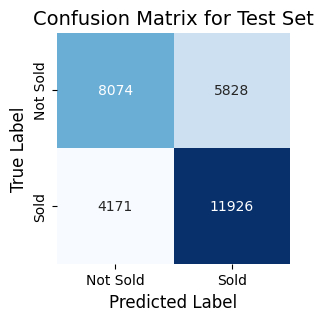

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plotting the confusion matrix
plt.figure(figsize=(3, 3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Not Sold', 'Sold'], yticklabels=['Not Sold', 'Sold'])
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.title('Confusion Matrix for Test Set', fontsize=14)
plt.show()

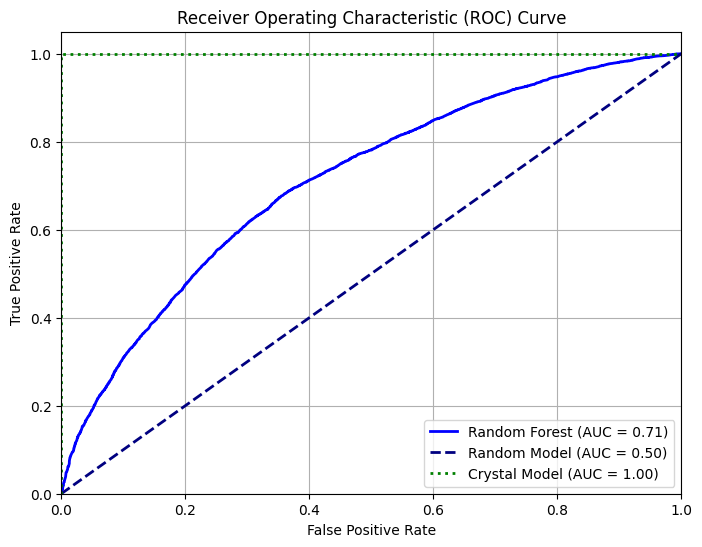

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Calculate ROC curve for the Random Forest model
fpr_rf, tpr_rf, thresholds_rf = roc_curve(y_test, y_proba)
auc_rf = auc(fpr_rf, tpr_rf)

plt.figure(figsize=(8, 6))

# Plot the Random Forest ROC curve
plt.plot(fpr_rf, tpr_rf, color='blue', lw=2, label=f'Random Forest (AUC = {auc_rf:.2f})')

# Plot the random model (diagonal line)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Model (AUC = 0.50)')

# Plot the "crystal" (perfect) model
plt.plot([0, 0, 1], [0, 1, 1], color='green', lw=2, linestyle=':', label='Crystal Model (AUC = 1.00)')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

## Feature Selection


/tmp/ipykernel_629/2462182547.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importance_mean', y='feature', data=importance_df_sorted, palette='viridis')


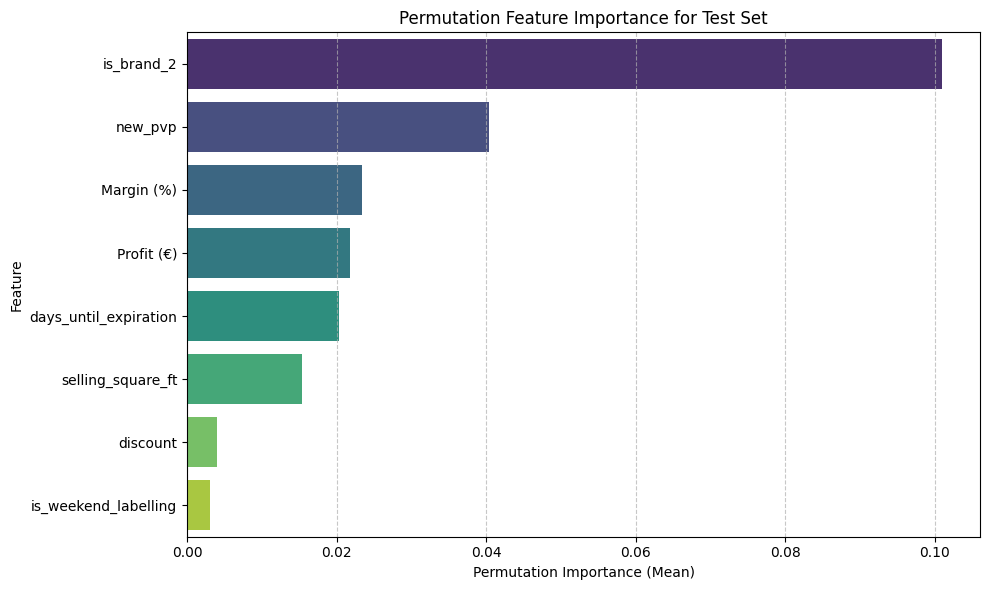

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ordendo por importancia das features
importance_df_sorted = importance_df.sort_values(by='importance_mean', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='importance_mean', y='feature', data=importance_df_sorted, palette='viridis')
plt.xlabel('Permutation Importance (Media)')
plt.ylabel('Feature')
plt.title('Permutation Feature Importance')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Analysis of Brand 2


In [ ]:
from sklearn.metrics import classification_report

# Filtrar o test set por 'brand' == 2 (onde 'is_brand_2' e 1)
brand_2_mask = test_processed['is_brand_2'] == 1
X_test_brand_2 = X_test[brand_2_mask]
y_test_brand_2 = y_test[brand_2_mask]
y_pred_brand_2 = y_pred[brand_2_mask]

print("\n=== CLASSIFICATION REPORT (BRAND == 2) ===")
print(classification_report(y_test_brand_2, y_pred_brand_2))


=== CLASSIFICATION REPORT FOR TEST SET (BRAND == 2) ===
              precision    recall  f1-score   support

           0       0.61      0.30      0.40      8054
           1       0.67      0.88      0.76     13116

    accuracy                           0.66     21170
   macro avg       0.64      0.59      0.58     21170
weighted avg       0.65      0.66      0.63     21170



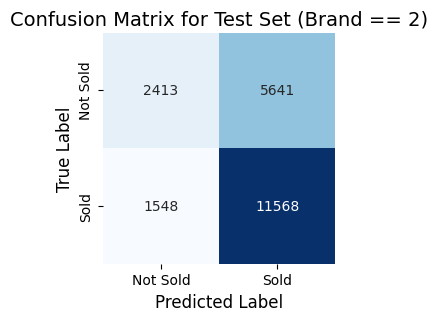

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Compute confusion matrix for brand 2
cm_brand_2 = confusion_matrix(y_test_brand_2, y_pred_brand_2)

# Plotting the confusion matrix
plt.figure(figsize=(3, 3))
sns.heatmap(cm_brand_2, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Not Sold', 'Sold'], yticklabels=['Not Sold', 'Sold'])
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.title('Confusion Matrix for Test Set (Brand == 2)', fontsize=14)
plt.show()

In [ ]:
print(f"Number of data points where brand is 2 in the test set: {len(X_test_brand_2)}")

Number of data points where brand is 2 in the test set: 21170


In [ ]:
print(f"Number of data points in the entire test set: {len(test_raw)}")

Number of data points in the entire test set: 29999


This analysis showed that the results were strongly influenced by Brand 2 when it was included as a feature, given the large number of observations associated with this brand. Because of the recall penalty, we decided not to use this feature in future iterations.


### Continuing Feature Selection


In [ ]:
from sklearn.metrics import accuracy_score

# Decidimos ver o top 5 de features por importancia
top_n_features = 5
selected_features = importance_df.head(top_n_features)['feature'].tolist()

print(f"Top features para o Modelo: {selected_features}")

X_train_reduced = train_processed[selected_features]
X_test_reduced = test_processed[selected_features]

reduced_rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=20,
    random_state=42,
    n_jobs=-1
)

reduced_rf_model.fit(X_train_reduced, y_train_full)

y_pred_reduced = reduced_rf_model.predict(X_test_reduced)
y_proba_reduced = reduced_rf_model.predict_proba(X_test_reduced)[:, 1]

print("\n=== CLASSIFICATION REPORT (REDUCED FEATURE) ===")
print(classification_report(y_test, y_pred_reduced))

accuracy_reduced = accuracy_score(y_test, y_pred_reduced)
print(f"Test Set Accuracy Score (Reduced Features): {accuracy_reduced:.4f}")

# Comparar com o resultado original
accuracy_full = accuracy_score(y_test, y_pred)

print(f"\nOriginal Model Test Set Accuracy Score (Full Features): {accuracy_full:.4f}")
print(f"Accuracy Drop-off: {accuracy_full - accuracy_reduced:.4f}")

Selected features for the reduced model: ['is_brand_2', 'new_pvp', 'Margin (%)', 'Profit (€)', 'days_until_expiration']

Training model with reduced features...

=== CLASSIFICATION REPORT (REDUCED FEATURE TEST SET) ===
              precision    recall  f1-score   support

           0       0.65      0.57      0.61     13902
           1       0.66      0.74      0.70     16097

    accuracy                           0.66     29999
   macro avg       0.66      0.65      0.65     29999
weighted avg       0.66      0.66      0.66     29999

Test Set Accuracy Score (Reduced Features): 0.6605

Original Model Test Set Accuracy Score (Full Features): 0.6667
Accuracy Drop-off: 0.0062


In [ ]:
from sklearn.metrics import accuracy_score

# Decidimos ver o top 4 de features por importancia

top_n_features = 4
selected_features = importance_df.head(top_n_features)['feature'].tolist()

print(f"Top features para o Modelo: {selected_features}")

X_train_reduced = train_processed[selected_features]
X_test_reduced = test_processed[selected_features]

reduced_rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=20,
    random_state=42,
    n_jobs=-1
)

print("\nTraining model with reduced features...")
reduced_rf_model.fit(X_train_reduced, y_train_full)

y_pred_reduced = reduced_rf_model.predict(X_test_reduced)
y_proba_reduced = reduced_rf_model.predict_proba(X_test_reduced)[:, 1]

print("\n=== CLASSIFICATION REPORT (REDUCED FEATURE TEST SET) ===")
print(classification_report(y_test, y_pred_reduced))

accuracy_reduced = accuracy_score(y_test, y_pred_reduced)
print(f"Test Set Accuracy Score (Reduced Features): {accuracy_reduced:.4f}")

# Comparar com o resultado original


accuracy_full = accuracy_score(y_test, y_pred)

print(f"\nOriginal Model Test Set Accuracy Score (Full Features): {accuracy_full:.4f}")
print(f"Accuracy Drop-off: {accuracy_full - accuracy_reduced:.4f}")

Selected features for the reduced model: ['is_brand_2', 'new_pvp', 'Margin (%)', 'Profit (€)']

Training model with reduced features...

=== CLASSIFICATION REPORT (REDUCED FEATURE TEST SET) ===
              precision    recall  f1-score   support

           0       0.66      0.53      0.59     13902
           1       0.65      0.76      0.70     16097

    accuracy                           0.65     29999
   macro avg       0.65      0.64      0.64     29999
weighted avg       0.65      0.65      0.65     29999

Test Set Accuracy Score (Reduced Features): 0.6529

Original Model Test Set Accuracy Score (Full Features): 0.6667
Accuracy Drop-off: 0.0138


In [ ]:
from sklearn.metrics import accuracy_score

top_n_features = 3
selected_features = importance_df.head(top_n_features)['feature'].tolist()

print(f"Top features para o Modelo: {selected_features}")

X_train_reduced = train_processed[selected_features]
X_test_reduced = test_processed[selected_features]

reduced_rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=20,
    random_state=42,
    n_jobs=-1
)

print("\nTraining model with reduced features...")
reduced_rf_model.fit(X_train_reduced, y_train_full)

y_pred_reduced = reduced_rf_model.predict(X_test_reduced)
y_proba_reduced = reduced_rf_model.predict_proba(X_test_reduced)[:, 1]

print("\n=== CLASSIFICATION REPORT (REDUCED FEATURE TEST SET) ===")
print(classification_report(y_test, y_pred_reduced))

accuracy_reduced = accuracy_score(y_test, y_pred_reduced)
print(f"Test Set Accuracy Score (Reduced Features): {accuracy_reduced:.4f}")

# Comparar com o resultado original
accuracy_full = accuracy_score(y_test, y_pred)

print(f"\nOriginal Model Test Set Accuracy Score (Full Features): {accuracy_full:.4f}")
print(f"Accuracy Drop-off: {accuracy_full - accuracy_reduced:.4f}")

Selected features for the reduced model: ['new_pvp', 'Margin (%)', 'Profit (€)']

Training model with reduced features...

=== CLASSIFICATION REPORT (REDUCED FEATURE TEST SET) ===
              precision    recall  f1-score   support

           0       0.63      0.57      0.60     13902
           1       0.66      0.71      0.68     16097

    accuracy                           0.64     29999
   macro avg       0.64      0.64      0.64     29999
weighted avg       0.64      0.64      0.64     29999

Test Set Accuracy Score (Reduced Features): 0.6449

Original Model Test Set Accuracy Score (Full Features): 0.6605
Accuracy Drop-off: 0.0156


In [ ]:
from sklearn.metrics import accuracy_score, roc_auc_score


top_n_features = 2
selected_features = importance_df.head(top_n_features)['feature'].tolist()

print(f"Top features para o Modelo: {selected_features}")

X_train_reduced = train_processed[selected_features]
X_test_reduced = test_processed[selected_features]

reduced_rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=20,
    random_state=42,
    n_jobs=-1
)

print("\nTraining model with reduced features...")
reduced_rf_model.fit(X_train_reduced, y_train_full)

y_pred_reduced = reduced_rf_model.predict(X_test_reduced)
y_proba_reduced = reduced_rf_model.predict_proba(X_test_reduced)[:, 1]

print("\n=== CLASSIFICATION REPORT (REDUCED FEATURE TEST SET) ===")
print(classification_report(y_test, y_pred_reduced))

accuracy_reduced = accuracy_score(y_test, y_pred_reduced)
print(f"Test Set Accuracy Score (Reduced Features): {accuracy_reduced:.4f}")

roc_auc_reduced = roc_auc_score(y_test, y_proba_reduced)
print(f"Test Set ROC-AUC Score (Reduced Features): {roc_auc_reduced:.4f}")

# Comparar com o resultado original

accuracy_full = accuracy_score(y_test, y_pred)
print(f"\nOriginal Model Test Set Accuracy Score (Full Features): {accuracy_full:.4f}")
print(f"Accuracy Drop-off: {accuracy_full - accuracy_reduced:.4f}")



Selected features for the reduced model: ['new_pvp', 'Margin (%)']

Training model with reduced features...

=== CLASSIFICATION REPORT (REDUCED FEATURE TEST SET) ===
              precision    recall  f1-score   support

           0       0.63      0.58      0.60     13902
           1       0.66      0.70      0.68     16097

    accuracy                           0.64     29999
   macro avg       0.64      0.64      0.64     29999
weighted avg       0.64      0.64      0.64     29999

Test Set Accuracy Score (Reduced Features): 0.6447
Test Set ROC-AUC Score (Reduced Features): 0.6894

Original Model Test Set Accuracy Score (Full Features): 0.6605
Accuracy Drop-off: 0.0158
Original Model Test Set ROC-AUC Score (Full Features): 0.7114
ROC-AUC Drop-off: 0.0220


## Conclusion


We concluded that reducing the number of features to four resulted in a performance decrease of approximately 1% compared with the original feature set. We therefore continued with the top four features in the next iteration.
